# Image Segmentation for Nucleus-to-Cytoplasm Ratio Estimation

**Project type:** Machine Learning / Computer Vision / Image Processing  
**Goal:** Segment cell images into **background**, **cytoplasm**, and **nucleus**, then use the predicted mask to estimate the **nucleus-to-cytoplasm (N/C) ratio**.

## Project Summary

In this project, I built an image segmentation pipeline for cell images. Each predicted mask classifies pixels into three classes:

- `0` = background
- `1` = cytoplasm
- `2` = nucleus

After predicting the segmentation mask, I calculate the **N/C ratio**:

$$
\text{N/C ratio} = \frac{\text{nucleus pixels}}{\text{cytoplasm pixels}}
$$

I compare three approaches:

1. **Hand-picked thresholding baseline**
2. **Optimized thresholding baseline**
3. **Random Forest pixel classifier**

The project is evaluated using:

- **Dice score** for segmentation quality
- **Mean Absolute Error (MAE)** for N/C ratio prediction accuracy
- **Within ±0.05 accuracy** for how often the predicted N/C ratio is close to the true value
- Visual comparison between predicted masks and ground-truth masks

The main purpose of the project is to show a complete machine learning workflow: create a baseline, improve the baseline, train a supervised model, evaluate the results, and explain the tradeoff between segmentation quality and downstream measurement accuracy.


## 0. Setup

This cell imports the libraries used in the project.

In [2]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error

np.random.seed(42)

## 1. Load the Dataset

The dataset is expected to contain:

```text
imagedata/X/0.npy, 1.npy, 2.npy, ...   # RGB cell images
imagedata/y/0.npy, 1.npy, 2.npy, ...   # segmentation masks
```

If this notebook is running in Colab and the dataset is not already present, it will clone the public lab repository that contains the image data.

In [3]:
# If the data folder is missing, clone the lab repository.
# This makes the notebook easier to run in Google Colab.
if not os.path.exists("imagedata/X"):
    print("Dataset not found locally. Cloning repository...")
    !git clone https://github.com/AxelRaphael29/VocEd
    %cd VocEd
else:
    print("Dataset found locally.")

x_files = sorted(glob.glob("imagedata/X/*.npy"), key=lambda p: int(os.path.splitext(os.path.basename(p))[0]))
y_files = sorted(glob.glob("imagedata/y/*.npy"), key=lambda p: int(os.path.splitext(os.path.basename(p))[0]))

print(f"Number of image files: {len(x_files)}")
print(f"Number of mask files:  {len(y_files)}")

X = np.stack([np.load(path) for path in x_files])
y = np.stack([np.load(path) for path in y_files])

# Some image arrays are channel-first: (N, 3, H, W). Keep that format internally.
# Normalize image values to 0-1 if needed.
X = X.astype(np.float32)
if X.max() > 1.5:
    X = X / 255.0

y = y.astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Image value range:", X.min(), "to", X.max())
print("Mask labels:", np.unique(y))

Dataset not found locally. Cloning repository...
Cloning into 'VocEd'...
remote: Enumerating objects: 452, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 452 (delta 19), reused 13 (delta 13), pack-reused 428 (from 1)
Receiving objects: 100% (452/452), 25.25 MiB | 24.37 MiB/s, done.
Resolving deltas: 100% (276/276), done.
/content/VocEd
Number of image files: 200
Number of mask files:  200
X shape: (200, 3, 256, 256)
y shape: (200, 256, 256)
Image value range: 0.0 to 1.0
Mask labels: [0 1 2]


## 2. Visualize One Image and Its Ground-Truth Mask

Before training anything, I first check that the image and mask are loading correctly.

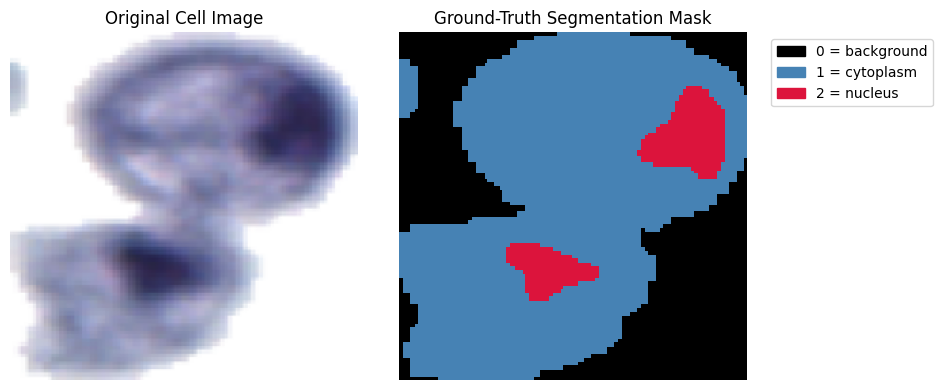

In [4]:
mask_cmap = ListedColormap(["black", "steelblue", "crimson"])
legend_patches = [
    mpatches.Patch(color="black", label="0 = background"),
    mpatches.Patch(color="steelblue", label="1 = cytoplasm"),
    mpatches.Patch(color="crimson", label="2 = nucleus"),
]

def to_hwc(img):
    """Convert image from channel-first (3, H, W) to channel-last (H, W, 3) for plotting."""
    if img.ndim == 3 and img.shape[0] == 3:
        return np.transpose(img, (1, 2, 0))
    return img

sample_index = 0

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(to_hwc(X[sample_index]))
plt.title("Original Cell Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(y[sample_index], cmap=mask_cmap, vmin=0, vmax=2, interpolation="nearest")
plt.title("Ground-Truth Segmentation Mask")
plt.axis("off")
plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 3. Define Evaluation Functions

The project uses two main evaluation ideas:

### Dice Score
Dice score measures how much the predicted mask overlaps with the true mask.

- Higher Dice score = better segmentation
- Lower Dice score = worse segmentation

In this notebook, Dice score is averaged over the **cytoplasm** and **nucleus** classes. Background is excluded from the average because the background can take up a large part of the image and make the score look better than the biologically important regions actually are.

### N/C Ratio Error
After creating a mask, I calculate:

$$
\text{N/C ratio} = \frac{\text{number of nucleus pixels}}{\text{number of cytoplasm pixels}}
$$

Then I compare the predicted ratio against the true ratio using Mean Absolute Error.


In [5]:
def nc_ratio(mask):
    """Calculate nucleus-to-cytoplasm ratio from a segmentation mask."""
    nucleus_pixels = np.sum(mask == 2)
    cytoplasm_pixels = np.sum(mask == 1)
    if cytoplasm_pixels == 0:
        return np.nan
    return nucleus_pixels / cytoplasm_pixels


def dice_score(pred, target, cls):
    """Calculate Dice score for one class."""
    pred_mask = pred == cls
    target_mask = target == cls
    intersection = np.sum(pred_mask & target_mask)
    denominator = np.sum(pred_mask) + np.sum(target_mask)
    if denominator == 0:
        return 1.0
    return 2 * intersection / denominator


def mean_dice(pred, target):
    """Average Dice score for the biologically important classes: cytoplasm and nucleus."""
    cyto_dice = dice_score(pred, target, cls=1)
    nuc_dice = dice_score(pred, target, cls=2)
    return (cyto_dice + nuc_dice) / 2


def evaluate_predictions(pred_masks, true_masks, name="model"):
    """Evaluate segmentation masks using Dice score and N/C ratio error."""
    dice_scores = np.array([mean_dice(p, t) for p, t in zip(pred_masks, true_masks)])
    true_ratios = np.array([nc_ratio(t) for t in true_masks])
    pred_ratios = np.array([nc_ratio(p) for p in pred_masks])

    valid = np.isfinite(true_ratios) & np.isfinite(pred_ratios)
    ratio_mae = mean_absolute_error(true_ratios[valid], pred_ratios[valid])
    within_05 = np.mean(np.abs(true_ratios[valid] - pred_ratios[valid]) <= 0.05)

    return {
        "method": name,
        "mean_dice": float(np.mean(dice_scores)),
        "nc_ratio_mae": float(ratio_mae),
        "within_05": float(within_05),
        "true_ratios": true_ratios,
        "pred_ratios": pred_ratios,
        "dice_scores": dice_scores,
    }


## 4. Train/Test Split

I split the data by **image**, not by individual pixel. This is important because it means the final evaluation is performed on held-out test images that were not used during threshold optimization or Random Forest training.

Images with no nucleus pixels are removed because the N/C ratio calculation requires a nucleus and cytoplasm structure. The split is stratified by N/C ratio quartiles when possible so that the training and test sets have similar ratio distributions.


In [6]:
# Remove images with no nucleus pixels, because N/C ratio requires nucleus and cytoplasm structure.
initial_image_count = len(X)
has_nucleus = np.sum(y == 2, axis=(1, 2)) > 0
X = X[has_nucleus]
y = y[has_nucleus]

# Stratify by N/C ratio so the train and test sets have similar ratio distributions.
all_ratios = np.array([nc_ratio(mask) for mask in y])
stratify_labels = np.digitize(all_ratios, np.percentile(all_ratios, [25, 50, 75]))

# If stratification fails because of small class counts, fall back to a normal random split.
try:
    train_idx, test_idx = train_test_split(
        np.arange(len(X)),
        test_size=0.20,
        random_state=42,
        stratify=stratify_labels,
    )
except ValueError:
    train_idx, test_idx = train_test_split(
        np.arange(len(X)),
        test_size=0.20,
        random_state=42,
    )

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Original images loaded: {initial_image_count}")
print(f"Images after filtering: {len(X)}")
print(f"Training images: {len(X_train)}")
print(f"Testing images:  {len(X_test)}")


Original images loaded: 200
Images after filtering: 191
Training images: 152
Testing images:  39


## 5. Method 1 — Hand-Picked Thresholding Baseline

The first baseline uses simple grayscale thresholds:

- darker pixels are classified as nucleus
- medium-intensity pixels are classified as cytoplasm
- bright pixels are classified as background

This is a simple starting point. It gives me something to compare stronger methods against.

In [7]:
def grayscale(img):
    """Convert RGB image in channel-first format into grayscale."""
    return 0.299 * img[0] + 0.587 * img[1] + 0.114 * img[2]


def segment_threshold(img, t_nucleus=0.45, t_background=0.85):
    """Segment image using two grayscale thresholds."""
    gray = grayscale(img)
    pred = np.zeros(gray.shape, dtype=np.int64)
    pred[gray < t_nucleus] = 2
    pred[(gray >= t_nucleus) & (gray < t_background)] = 1
    return pred

pred_hand_threshold = np.array([
    segment_threshold(img, t_nucleus=0.45, t_background=0.85)
    for img in X_test
])

results_hand = evaluate_predictions(pred_hand_threshold, y_test, name="Hand-picked thresholding")

print("Hand-picked thresholding results")
print("Mean Dice:", round(results_hand["mean_dice"], 4))
print("N/C Ratio MAE:", round(results_hand["nc_ratio_mae"], 4))
print("Within ±0.05 N/C ratio:", f"{results_hand['within_05']:.1%}")


Hand-picked thresholding results
Mean Dice: 0.7441
N/C Ratio MAE: 0.6659
Within ±0.05 N/C ratio: 5.1%


## 6. Method 2 — Optimized Thresholding

Instead of choosing the thresholds manually, this section searches across many threshold combinations and picks the pair that gives the best average Dice score on the **training set only**.

The best thresholds are then evaluated on the held-out test images. This avoids using the test set to choose the threshold values.

This is still a simple image processing method, but it is more systematic than guessing the thresholds by hand.


In [8]:
def score_thresholds(t_nucleus, t_background, X_data, y_data):
    """Return average Dice score for a threshold pair."""
    if t_nucleus >= t_background:
        return -np.inf
    scores = []
    for img, mask in zip(X_data, y_data):
        pred = segment_threshold(img, t_nucleus, t_background)
        scores.append(mean_dice(pred, mask))
    return np.mean(scores)

# Grid search over possible threshold values.
nucleus_thresholds = np.linspace(0.10, 0.70, 25)
background_thresholds = np.linspace(0.50, 0.99, 25)

best_score = -np.inf
best_t_nucleus = None
best_t_background = None

for t_nuc in nucleus_thresholds:
    for t_bg in background_thresholds:
        score = score_thresholds(t_nuc, t_bg, X_train, y_train)
        if score > best_score:
            best_score = score
            best_t_nucleus = t_nuc
            best_t_background = t_bg

print("Best nucleus threshold:", round(best_t_nucleus, 4))
print("Best background threshold:", round(best_t_background, 4))
print("Best training Dice:", round(best_score, 4))

pred_optimized_threshold = np.array([
    segment_threshold(img, best_t_nucleus, best_t_background)
    for img in X_test
])

results_optimized = evaluate_predictions(pred_optimized_threshold, y_test, name="Optimized thresholding")

print("Optimized thresholding test results")
print("Mean Dice:", round(results_optimized["mean_dice"], 4))
print("N/C Ratio MAE:", round(results_optimized["nc_ratio_mae"], 4))
print("Within ±0.05 N/C ratio:", f"{results_optimized['within_05']:.1%}")


Best nucleus threshold: 0.4
Best background threshold: 0.99
Best training Dice: 0.7771
Optimized thresholding test results
Mean Dice: 0.8184
N/C Ratio MAE: 0.2315
Within ±0.05 N/C ratio: 25.6%


## 7. Method 3 — Random Forest Pixel Classifier

The Random Forest model treats segmentation as a supervised learning problem.

Each pixel becomes one training example. The input features are:

- red value
- green value
- blue value
- grayscale intensity
- normalized x-position
- normalized y-position

The target label is the true class of the pixel:

- background
- cytoplasm
- nucleus

Position features are included because cell structures often follow spatial patterns within an image. For example, nuclei often appear near the interior of a cell rather than randomly across the entire image.

To keep training fast, I sample a fixed number of pixels from the training images.


In [9]:
def pixel_features(img):
    """Create feature matrix for every pixel in one image."""
    c, h, w = img.shape
    rgb = img.reshape(3, -1).T
    gray = grayscale(img).reshape(-1, 1)
    yy, xx = np.mgrid[0:h, 0:w]
    x_pos = (xx.reshape(-1, 1) / max(w - 1, 1)).astype(np.float32)
    y_pos = (yy.reshape(-1, 1) / max(h - 1, 1)).astype(np.float32)
    return np.hstack([rgb, gray, x_pos, y_pos])


def sample_pixels(X_data, y_data, pixels_per_image=2000, random_state=42):
    """Sample pixels from training images to create a supervised learning dataset."""
    rng = np.random.default_rng(random_state)
    X_pixels = []
    y_pixels = []

    for img, mask in zip(X_data, y_data):
        features = pixel_features(img)
        labels = mask.reshape(-1)
        n_pixels = len(labels)
        n_sample = min(pixels_per_image, n_pixels)
        chosen = rng.choice(n_pixels, size=n_sample, replace=False)
        X_pixels.append(features[chosen])
        y_pixels.append(labels[chosen])

    return np.vstack(X_pixels), np.concatenate(y_pixels)

X_pixel_train, y_pixel_train = sample_pixels(
    X_train,
    y_train,
    pixels_per_image=2500,
    random_state=42,
)

print("Pixel training feature shape:", X_pixel_train.shape)
print("Pixel training label shape:", y_pixel_train.shape)
print("Class counts:")
print(pd.Series(y_pixel_train).value_counts().sort_index())

Pixel training feature shape: (380000, 6)
Pixel training label shape: (380000,)
Class counts:
0    137315
1    164539
2     78146
Name: count, dtype: int64


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=18,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample",
)

rf_model.fit(X_pixel_train, y_pixel_train)
print("Random Forest training complete.")

Random Forest training complete.


In [11]:
def predict_rf_mask(model, img):
    """Predict a full segmentation mask for one image using the trained Random Forest."""
    features = pixel_features(img)
    pred_flat = model.predict(features)
    h, w = img.shape[1], img.shape[2]
    return pred_flat.reshape(h, w)

pred_rf = np.array([predict_rf_mask(rf_model, img) for img in X_test])

results_rf = evaluate_predictions(pred_rf, y_test, name="Random Forest pixel classifier")

print("Random Forest test results")
print("Mean Dice:", round(results_rf["mean_dice"], 4))
print("N/C Ratio MAE:", round(results_rf["nc_ratio_mae"], 4))
print("Within ±0.05 N/C ratio:", f"{results_rf['within_05']:.1%}")


Random Forest test results
Mean Dice: 0.816
N/C Ratio MAE: 0.1945
Within ±0.05 N/C ratio: 41.0%


### Random Forest Feature Importance

This plot shows which pixel features the Random Forest relied on most when making predictions. It helps make the model more interpretable.


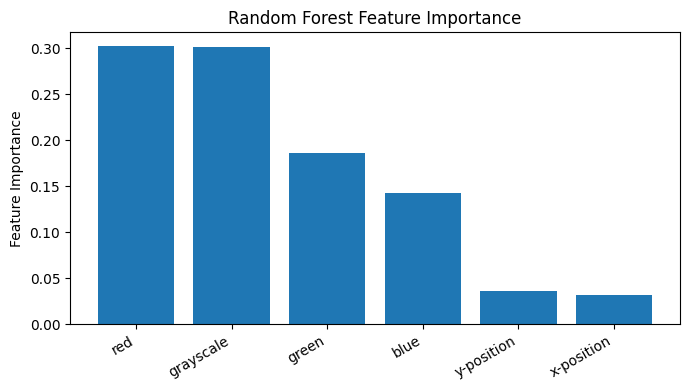

,Feature,Importance
0,red,0.302431
3,grayscale,0.301817
1,green,0.185789
2,blue,0.142460
5,y-position,0.035597
4,x-position,0.031905


In [12]:
feature_names = ["red", "green", "blue", "grayscale", "x-position", "y-position"]
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_,
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

importance_df


## 8. Final Results Table

This table compares all three methods.

For this project:

- Higher **Mean Dice** is better.
- Lower **N/C Ratio MAE** is better.
- Higher **Within ±0.05** is better.

In [13]:
all_results = [results_hand, results_optimized, results_rf]

summary_df = pd.DataFrame([
    {
        "Method": r["method"],
        "Mean Dice": r["mean_dice"],
        "N/C Ratio MAE": r["nc_ratio_mae"],
        "Within ±0.05": r["within_05"],
    }
    for r in all_results
])

summary_df = summary_df.sort_values(by="N/C Ratio MAE", ascending=True).reset_index(drop=True)
summary_df.insert(0, "Rank by N/C MAE", np.arange(1, len(summary_df) + 1))
summary_df


,Rank by N/C MAE,Method,Mean Dice,N/C Ratio MAE,Within ±0.05
0,1,Random Forest pixel classifier,0.815970,0.194451,0.410256
1,2,Optimized thresholding,0.818379,0.231524,0.256410
2,3,Hand-picked thresholding,0.744094,0.665870,0.051282


## 9. Predicted vs. True N/C Ratio

A perfect model would fall directly on the dashed line.

- Points near the line = accurate N/C ratio prediction
- Points far from the line = larger error

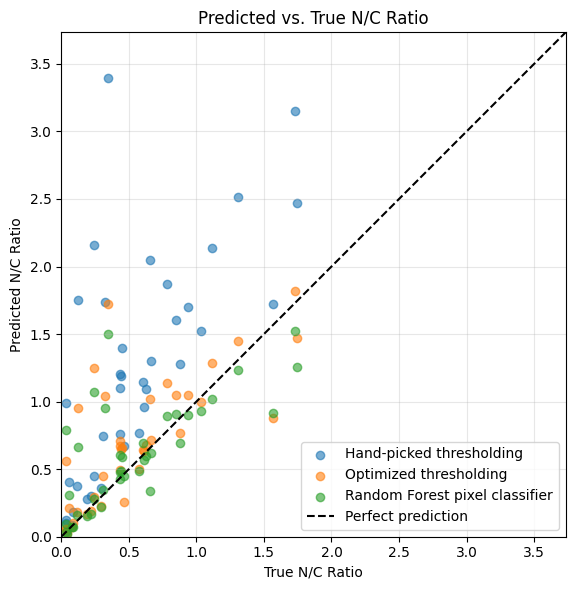

In [14]:
plt.figure(figsize=(7, 6))

for r in all_results:
    true_ratios = r["true_ratios"]
    pred_ratios = r["pred_ratios"]
    valid = np.isfinite(true_ratios) & np.isfinite(pred_ratios)
    plt.scatter(true_ratios[valid], pred_ratios[valid], alpha=0.6, label=r["method"])

max_ratio = 0
for r in all_results:
    max_ratio = max(max_ratio, np.nanmax(r["true_ratios"]), np.nanmax(r["pred_ratios"]))
max_ratio *= 1.1

plt.plot([0, max_ratio], [0, max_ratio], "k--", label="Perfect prediction")
plt.xlabel("True N/C Ratio")
plt.ylabel("Predicted N/C Ratio")
plt.title("Predicted vs. True N/C Ratio")
plt.xlim(0, max_ratio)
plt.ylim(0, max_ratio)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Visual Comparison of Segmentation Results

This section shows the original image, true mask, and predicted masks from the different methods.

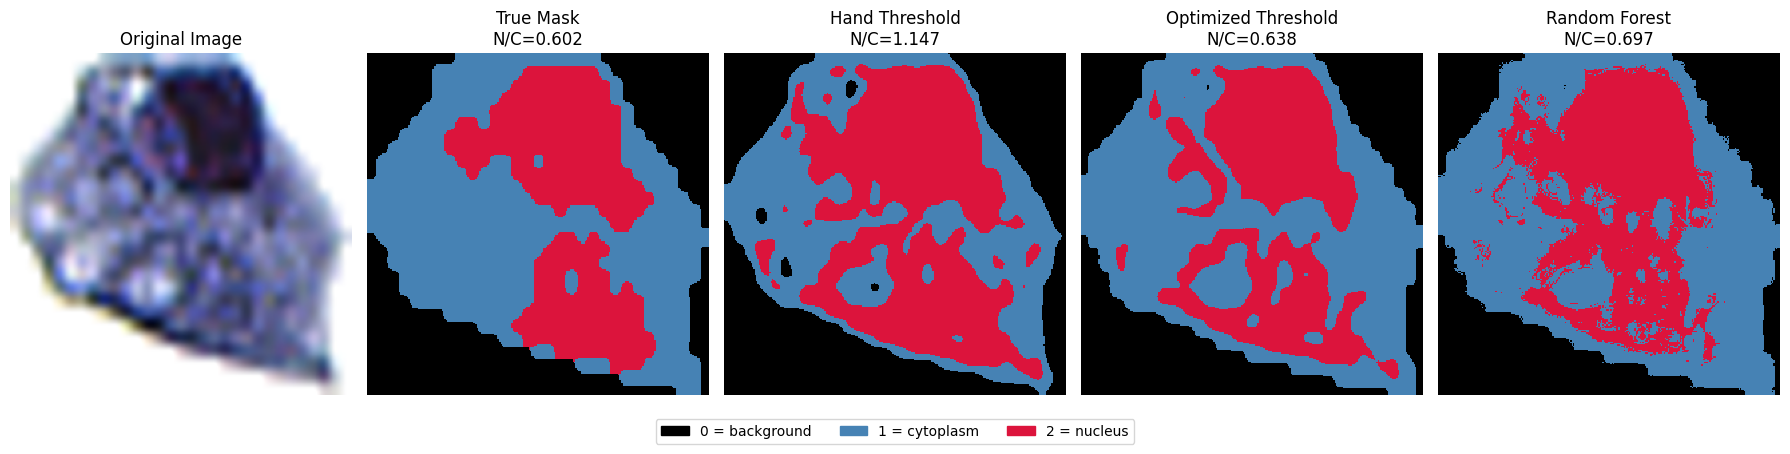

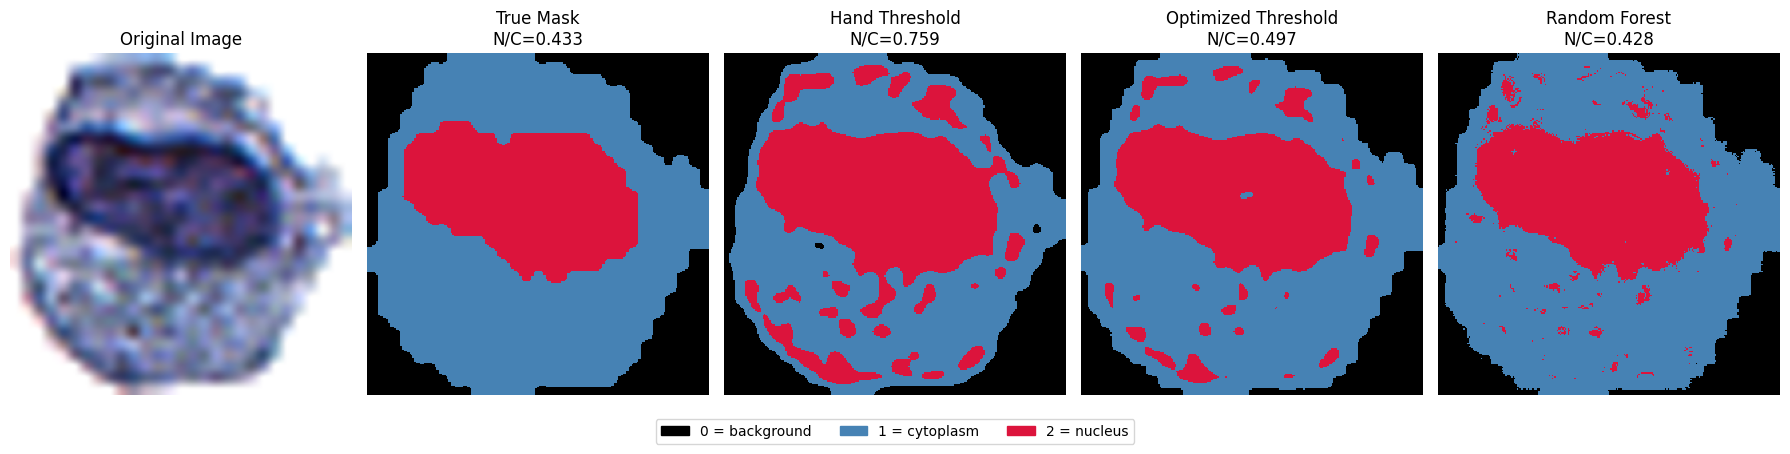

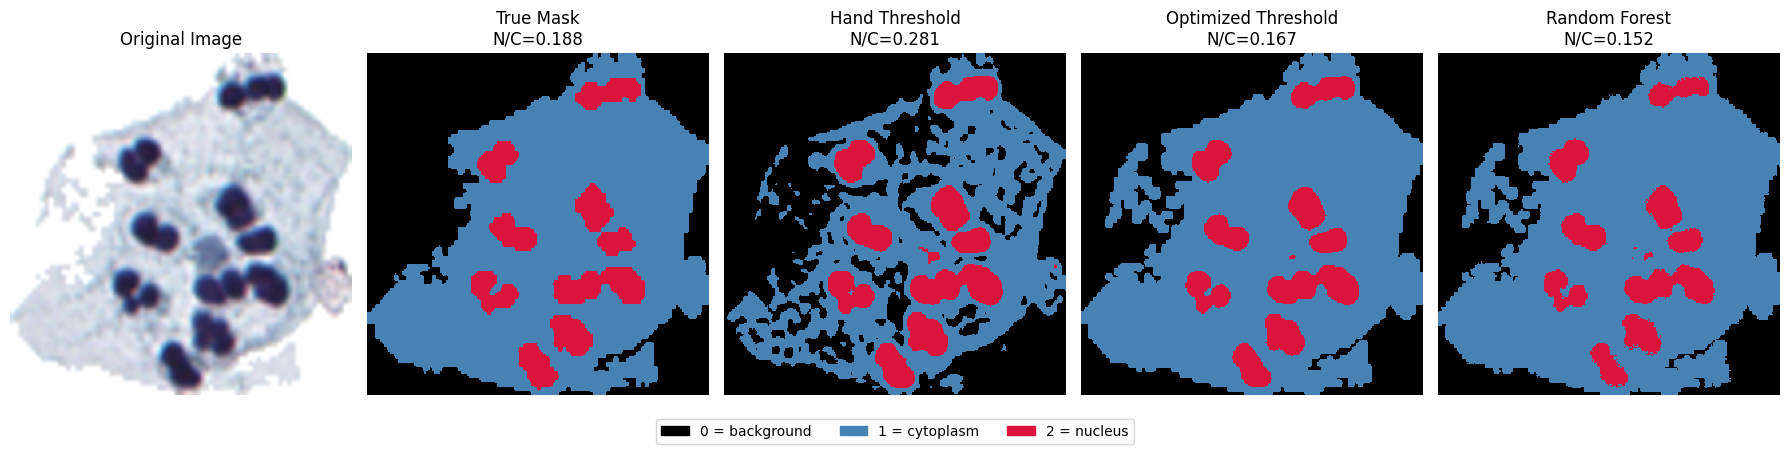

In [15]:
def show_segmentation_comparison(test_number=0):
    img = X_test[test_number]
    true_mask = y_test[test_number]
    hand_mask = pred_hand_threshold[test_number]
    opt_mask = pred_optimized_threshold[test_number]
    rf_mask = pred_rf[test_number]

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))

    axes[0].imshow(to_hwc(img))
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(true_mask, cmap=mask_cmap, vmin=0, vmax=2, interpolation="nearest")
    axes[1].set_title(f"True Mask\nN/C={nc_ratio(true_mask):.3f}")
    axes[1].axis("off")

    axes[2].imshow(hand_mask, cmap=mask_cmap, vmin=0, vmax=2, interpolation="nearest")
    axes[2].set_title(f"Hand Threshold\nN/C={nc_ratio(hand_mask):.3f}")
    axes[2].axis("off")

    axes[3].imshow(opt_mask, cmap=mask_cmap, vmin=0, vmax=2, interpolation="nearest")
    axes[3].set_title(f"Optimized Threshold\nN/C={nc_ratio(opt_mask):.3f}")
    axes[3].axis("off")

    axes[4].imshow(rf_mask, cmap=mask_cmap, vmin=0, vmax=2, interpolation="nearest")
    axes[4].set_title(f"Random Forest\nN/C={nc_ratio(rf_mask):.3f}")
    axes[4].axis("off")

    fig.legend(handles=legend_patches, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08))
    plt.tight_layout()
    plt.show()

for i in range(min(3, len(X_test))):
    show_segmentation_comparison(i)

## 11. Error Distribution

This plot shows how large the N/C ratio errors are across the test set.

A better model should have more errors concentrated close to 0.

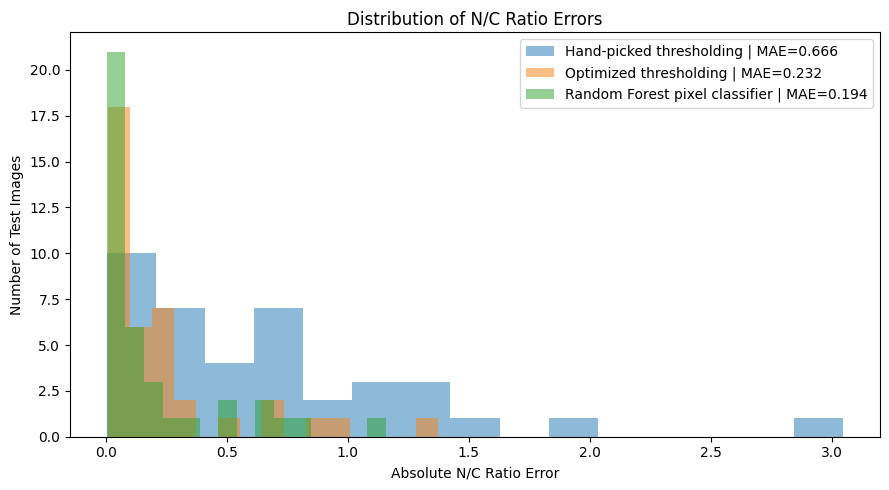

In [16]:
plt.figure(figsize=(9, 5))

for r in all_results:
    true_ratios = r["true_ratios"]
    pred_ratios = r["pred_ratios"]
    valid = np.isfinite(true_ratios) & np.isfinite(pred_ratios)
    errors = np.abs(true_ratios[valid] - pred_ratios[valid])
    plt.hist(errors, bins=15, alpha=0.5, label=f"{r['method']} | MAE={r['nc_ratio_mae']:.3f}")

plt.xlabel("Absolute N/C Ratio Error")
plt.ylabel("Number of Test Images")
plt.title("Distribution of N/C Ratio Errors")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Project Conclusion

I started this project because I wanted to practice supervised learning on image data instead of only working with simple tabular datasets. I chose this project because it helped me connect machine learning with image processing and real measurements.

This project explored how image segmentation can be used to estimate the nucleus-to-cytoplasm ratio from cell images. The goal was to classify each pixel as background, cytoplasm, or nucleus, then use the predicted mask to calculate the N/C ratio.

Three methods were tested: hand-picked thresholding, optimized thresholding, and a Random Forest pixel classifier. Hand-picked thresholding served as a simple baseline. Optimized thresholding improved the segmentation result by searching for better grayscale threshold values on the training set. The Random Forest pixel classifier achieved the lowest N/C ratio error on the held-out test set, making it the most accurate method for estimating the final N/C ratio measurement in this experiment.

One important takeaway is that the best segmentation score does not always produce the best final measurement. Optimized thresholding and Random Forest had similar Dice scores, but Random Forest produced a lower N/C ratio error. This showed me why it is useful to evaluate both mask quality and the accuracy of the downstream measurement.

### Limitations and Future Work

This project was tested on a relatively small image dataset, so the results may not generalize to all cell images. The Random Forest model used pixel-level features such as color, grayscale intensity, and position, but it does not understand larger image structures the way a convolutional neural network might. In the future, this project could be improved by testing on more images, adding data augmentation, and comparing the results with a CNN or U-Net segmentation model.


## 13. Save Results

This optional cell saves the results table as a CSV file.

In [ ]:
summary_df.to_csv("nc_ratio_segmentation_results.csv", index=False)
print("Saved results to nc_ratio_segmentation_results.csv")